## **Load dataset**

In [1]:
from datasets import load_dataset

# load dataset
ds= load_dataset("/kaggle/input/glasses-classification-dataset/train")
ds

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 104
    })
})

In [2]:
ClassLabel=ds["train"].features["label"].names

ClassLabel

['glasses', 'noglasses']

In [3]:
label2id, id2label = dict(), dict()
for i, label in enumerate(ClassLabel):
    label2id[label] = i
    id2label[i] = label
    
    
print("lebel2id :",label2id)
print("id2label :",id2label)

lebel2id : {'glasses': 0, 'noglasses': 1}
id2label : {0: 'glasses', 1: 'noglasses'}


## **Preprocessing the data**

In [4]:
# split up training into training + validation
splits = ds['train'].train_test_split(test_size=0.2)
train_ds = splits['train']
val_ds = splits['test']
print(train_ds)

Dataset({
    features: ['image', 'label'],
    num_rows: 83
})


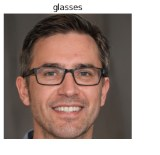

In [5]:
train_ds[0]["image"]

In [6]:
train_ds[0]["label"]

0

In [7]:

from transformers import ViTImageProcessor

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
processor

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [25]:
from torchvision.transforms import (CenterCrop, 
                                    Compose, 
                                    Normalize, 
                                    RandomHorizontalFlip,
                                    RandomResizedCrop, 
                                    Resize, 
                                    ToTensor)

image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]

normalize = Normalize(mean=image_mean, std=image_std)
_train_transforms = Compose([
            RandomResizedCrop(size),
            ToTensor(),
            normalize,])#RandomHorizontalFlip(),


_val_transforms = Compose([
            Resize(size),
            CenterCrop(size),
            ToTensor(),
            normalize,])

def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

In [26]:
# Set the transforms
train=train_ds.with_transform(train_transforms)
val=val_ds.with_transform(val_transforms)

#train=train_ds.map(train_transforms, batched=True)
#val=val_ds.map(train_transforms, batched=True)

In [11]:
print(train[:2])

{'image': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=160x155 at 0x7E6E4CF33FA0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=159x156 at 0x7E6E4CF32CB0>], 'label': [0, 0], 'pixel_values': [tensor([[[-0.7176, -0.7255, -0.7490,  ...,  1.0000,  1.0000,  1.0000],
         [-0.7333, -0.7333, -0.7490,  ...,  1.0000,  1.0000,  1.0000],
         [-0.7647, -0.7647, -0.7569,  ...,  1.0000,  1.0000,  1.0000],
         ...,
         [ 0.9843,  0.9922,  0.9922,  ...,  1.0000,  1.0000,  1.0000],
         [ 0.9922,  1.0000,  0.9922,  ...,  1.0000,  1.0000,  1.0000],
         [ 1.0000,  1.0000,  0.9922,  ...,  1.0000,  1.0000,  1.0000]],

        [[-0.7725, -0.7961, -0.8431,  ...,  1.0000,  1.0000,  1.0000],
         [-0.7961, -0.8118, -0.8510,  ...,  1.0000,  1.0000,  1.0000],
         [-0.8431, -0.8510, -0.8588,  ...,  1.0000,  1.0000,  1.0000],
         ...,
         [ 0.9529,  0.9608,  0.9686,  ...,  1.0000,  1.0000,  1.0000],
         [ 0.9843,  0.9765,  0.9765,  ...,  1.00

In [27]:

from torch.utils.data import DataLoader
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}



In [30]:
train_batch_size=4
train_dataloader = DataLoader(train, collate_fn=collate_fn, batch_size=train_batch_size)
val_dataloader = DataLoader(val, collate_fn=collate_fn, batch_size=train_batch_size)

In [31]:

batch = next(iter(train_dataloader))
for k,v in batch.items():
  if isinstance(v, torch.Tensor):
    print(k, v.shape)

pixel_values torch.Size([4, 3, 224, 224])
labels torch.Size([4])


In [32]:
assert batch['pixel_values'].shape == (train_batch_size, 3, 224, 224)
assert batch['labels'].shape == (train_batch_size,)

In [34]:
next(iter(val_dataloader))['pixel_values'].shape

torch.Size([4, 3, 224, 224])

## **Define the model use huggingface API and Trainer**

In [35]:

from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k',
                                                  id2label=id2label,
                                                  label2id=label2id)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [36]:
from transformers import TrainingArguments, Trainer

metric_name = "accuracy"

args = TrainingArguments(
    output_dir="./test-cifar-10",
    save_strategy="epoch",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=5,
    per_device_eval_batch_size=5,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model=metric_name,
    logging_dir='logs',
    remove_unused_columns=False,
)

In [37]:
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return dict(accuracy=accuracy_score(predictions, labels))

In [38]:
import torch

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train,
    eval_dataset=val,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    tokenizer=processor,
)
  

In [88]:

# Start tensorboard.
%load_ext tensorboard
%tensorboard --logdir logs/
     

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [39]:
trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()


wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:


Abort: 

## **Define the model - LightningModule**

In [40]:
import pytorch_lightning as pl
from transformers import ViTForImageClassification, AdamW
import torch.nn as nn

class ViTLightningModule(pl.LightningModule):
    def __init__(self, num_labels=10):
        super(ViTLightningModule, self).__init__()
        self.vit = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k',
                                                              num_labels=2,
                                                              id2label=id2label,
                                                              label2id=label2id)

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        return outputs.logits
        
    def common_step(self, batch, batch_idx):
        pixel_values = batch['pixel_values']
        labels = batch['labels']
        logits = self(pixel_values)

        criterion = nn.CrossEntropyLoss()
        loss = criterion(logits, labels)
        predictions = logits.argmax(-1)
        correct = (predictions == labels).sum().item()
        accuracy = correct/pixel_values.shape[0]

        return loss, accuracy
      
    def training_step(self, batch, batch_idx):
        loss, accuracy = self.common_step(batch, batch_idx)     
        # logs metrics for each training_step,
        # and the average across the epoch
        self.log("training_loss", loss)
        self.log("training_accuracy", accuracy)

        return loss
    
    def validation_step(self, batch, batch_idx):
        loss, accuracy = self.common_step(batch, batch_idx)     
        self.log("validation_loss", loss, on_epoch=True)
        self.log("validation_accuracy", accuracy, on_epoch=True)

        return loss

    def test_step(self, batch, batch_idx):
        loss, accuracy = self.common_step(batch, batch_idx)     

        return loss

    def configure_optimizers(self):
        # We could make the optimizer more fancy by adding a scheduler and specifying which parameters do
        # not require weight_decay but just using AdamW out-of-the-box works fine
        return AdamW(self.parameters(), lr=5e-5)

    def train_dataloader(self):
        return train_dataloader

    def val_dataloader(self):
        return val_dataloader

    def test_dataloader(self):
        return test_dataloader

In [ ]:

from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

# for early stopping, see https://pytorch-lightning.readthedocs.io/en/1.0.0/early_stopping.html?highlight=early%20stopping
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    strict=False,
    verbose=False,
    mode='min'
)

model = ViTLightningModule()
trainer = Trainer(callbacks=[EarlyStopping(monitor='validation_loss')])
trainer.fit(model)
     

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/pytorch_lightning/loops/utilities.py:72: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:298: The number of training batches (21) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]